In [1]:
!mkdir -p ~/.kaggle

In [2]:
!cp kaggle.json ~/.kaggle/

In [3]:
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle competitions download -c bike-sharing-demand

bike-sharing-demand.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
!unzip bike-sharing-demand.zip

Archive:  bike-sharing-demand.zip
  inflating: sampleSubmission.csv    
  inflating: test.csv                
  inflating: train.csv               


In [1]:
import pandas as pd

train_df=pd.read_csv('train.csv')
train_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [2]:
test_df=pd.read_csv('test.csv')
test_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014
...,...,...,...,...,...,...,...,...,...
6488,2012-12-31 19:00:00,1,0,1,2,10.66,12.880,60,11.0014
6489,2012-12-31 20:00:00,1,0,1,2,10.66,12.880,60,11.0014
6490,2012-12-31 21:00:00,1,0,1,1,10.66,12.880,60,11.0014
6491,2012-12-31 22:00:00,1,0,1,1,10.66,13.635,56,8.9981


In [3]:
#train -  casual, registered 불필요
#년,월,일,시간 -> 새로운 열로 삽입
#타겟 / 피처 분리해서 -> 텐서로 변환후
#딥러닝 모델 정의(linear 3개, dropout, relu)

#mseloss, adam
#=> 따릉이 대여량과 피처들간의 상관관계

In [4]:
# train -  casual, registered 불필요
train_df=train_df.drop(['casual', 'registered'], axis=1)
train_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,1
...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,129


In [5]:
#년,월,일,시간 -> 새로운 열로 삽입
train_df['datetime'] = pd.to_datetime(train_df['datetime'])
train_df['year']=train_df['datetime'].dt.year
train_df['month'] = train_df['datetime'].dt.month
train_df['day'] = train_df['datetime'].dt.day
train_df['hour'] = train_df['datetime'].dt.hour

train_df=train_df.drop(['datetime'], axis=1)
train_df

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,day,hour
0,1,0,0,1,9.84,14.395,81,0.0000,16,2011,1,1,0
1,1,0,0,1,9.02,13.635,80,0.0000,40,2011,1,1,1
2,1,0,0,1,9.02,13.635,80,0.0000,32,2011,1,1,2
3,1,0,0,1,9.84,14.395,75,0.0000,13,2011,1,1,3
4,1,0,0,1,9.84,14.395,75,0.0000,1,2011,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,4,0,1,1,15.58,19.695,50,26.0027,336,2012,12,19,19
10882,4,0,1,1,14.76,17.425,57,15.0013,241,2012,12,19,20
10883,4,0,1,1,13.94,15.910,61,15.0013,168,2012,12,19,21
10884,4,0,1,1,13.94,17.425,61,6.0032,129,2012,12,19,22


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [7]:
#타겟 / 피처 분리해서 -> 텐서로 변환후
features = train_df.drop('count', axis=1).values
target = train_df['count'].values

In [8]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [11]:
X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train_log).unsqueeze(1) 
X_test_t = torch.FloatTensor(X_test_scaled)
y_test_t = torch.FloatTensor(y_test_log).unsqueeze(1)

In [12]:
#딥러닝 모델 정의(linear 3개, dropout, relu)
class BikeModel(nn.Module):
    def __init__(self,input_dim):
        super().__init__()
        self.fc1=nn.Linear(input_dim, 256)
        self.fc2=nn.Linear(256, 64)
        self.fc3=nn.Linear(64, 1)
        self.relu=nn.ReLU()
        self.d1=nn.Dropout(0.2)
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.d1(x)
        x = self.relu(self.fc2(x))
        x = self.d1(x)
        x = self.fc3(x)
        return x

In [13]:
input_dim = X_train.shape[1]
model = BikeModel(input_dim)
mseloss = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

In [14]:
epochs = 2000
total_loss, total_acc = 0, 0
count=0

for epoch in range(epochs):
    model.train()
    
    output = model(X_train_t)
    loss = mseloss(output, y_train_t)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    
    if (epoch + 1) % 100 == 0:
        model.eval()
        with torch.no_grad():
            y_true = y_train_t.numpy()
            y_pred = output.detach().numpy()
            accuracy = r2_score(y_true, y_pred)
            total_acc += accuracy
            count+=1
            
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, R2 Score: {accuracy*100:.4f}')

avg_loss = total_loss / epochs
avg_acc = total_acc / count
print(f'Average Loss: {avg_loss:.4f}', f'Average R2 Score : {avg_acc*100:.4f}%')

Epoch [100/2000], Loss: 1.3794, R2 Score: 31.1572
Epoch [200/2000], Loss: 1.0373, R2 Score: 48.2313
Epoch [300/2000], Loss: 0.8936, R2 Score: 55.4018
Epoch [400/2000], Loss: 0.7816, R2 Score: 60.9915
Epoch [500/2000], Loss: 0.6522, R2 Score: 67.4487
Epoch [600/2000], Loss: 0.5575, R2 Score: 72.1761
Epoch [700/2000], Loss: 0.4849, R2 Score: 75.8007
Epoch [800/2000], Loss: 0.4736, R2 Score: 76.3614
Epoch [900/2000], Loss: 0.4426, R2 Score: 77.9104
Epoch [1000/2000], Loss: 0.4422, R2 Score: 77.9307
Epoch [1100/2000], Loss: 0.4173, R2 Score: 79.1736
Epoch [1200/2000], Loss: 0.4039, R2 Score: 79.8404
Epoch [1300/2000], Loss: 0.3820, R2 Score: 80.9369
Epoch [1400/2000], Loss: 0.3742, R2 Score: 81.3224
Epoch [1500/2000], Loss: 0.3645, R2 Score: 81.8076
Epoch [1600/2000], Loss: 0.3458, R2 Score: 82.7393
Epoch [1700/2000], Loss: 0.3326, R2 Score: 83.4010
Epoch [1800/2000], Loss: 0.3249, R2 Score: 83.7847
Epoch [1900/2000], Loss: 0.3184, R2 Score: 84.1100
Epoch [2000/2000], Loss: 0.3102, R2 Scor

In [15]:
model.eval()
with torch.no_grad():
    test_output = model(X_test_t)
    
    y_test_true = np.expm1(y_test_t.cpu().numpy())
    y_test_pred = np.expm1(test_output.cpu().numpy())

    test_r2 = r2_score(y_test_true, y_test_pred)
    test_loss = mseloss(test_output, y_test_t).item()

print(f'Test Loss: {test_loss:.4f}')
print(f'Test R2 Score: {test_r2 * 100:.4f}%')

Test Loss: 0.1592
Test R2 Score: 82.3560%


In [16]:
matrix = train_df.corr()
print(matrix['count'])

season        0.163439
holiday      -0.005393
workingday    0.011594
weather      -0.128655
temp          0.394454
atemp         0.389784
humidity     -0.317371
windspeed     0.101369
count         1.000000
year          0.260403
month         0.166862
day           0.019826
hour          0.400601
Name: count, dtype: float64


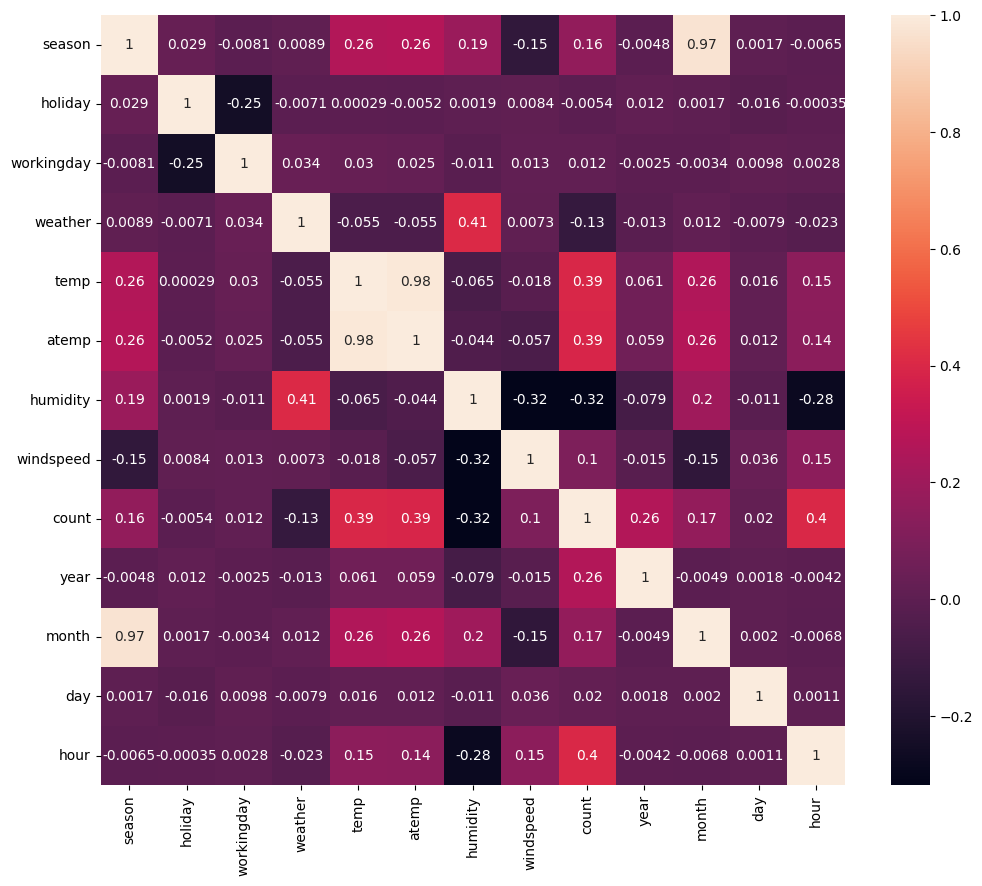

In [17]:
plt.figure(figsize=(12, 10))
sns.heatmap(train_df.corr(), annot=True)
plt.show()